In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
from collections import deque

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [5]:


# PHYSICAL PROPERTIES (WATER)


rho = 997.0
cp = 4180.0
k = 0.63
mu = 0.000653


# HEAT EXCHANGER GEOMETRY

D = 0.02
L = 20.0

A_heat = np.pi * D * L

# PROCESS CONDITIONS

T_cold_in = 25.0
T_target = 55.0

m_dot_cold = 0.30

# ACTION SPACE

actions = np.array([
    -0.05,
    -0.02,
    -0.01,
     0.00,
     0.01,
     0.02,
     0.05
])

n_actions = len(actions)

# DQN HYPERPARAMETERS

gamma = 0.95

epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

learning_rate = 0.001

batch_size = 64

memory_size = 10000

episodes = 3000


In [6]:
# REPLAY MEMORY

memory = deque(maxlen=memory_size)


In [7]:
# HEAT EXCHANGER MODEL

def hx_model(m_dot_hot, T_hot_in):

    m_dot_hot = max(m_dot_hot, 0.05)

    A_flow = np.pi * (D / 2)**2

    V = m_dot_hot / (rho * A_flow)

    Re = rho * V * D / mu

    Re = max(Re, 3000)

    Pr = cp * mu / k

    Nu = 0.023 * Re**0.8 * Pr**0.4

    h = Nu * k / D

    U = 0.9 * h

    # Capacity rates
    C_hot = m_dot_hot * cp
    C_cold = m_dot_cold * cp

    C_min = min(C_hot, C_cold)
    C_max = max(C_hot, C_cold)

    Cr = C_min / C_max

    # NTU
    NTU = U * A_heat / C_min

    # STABLE EFFECTIVENESS

    if abs(Cr - 1.0) < 1e-6:

        eps = NTU / (1 + NTU)

    else:

        numerator = (
            1 - np.exp(-NTU * (1 - Cr))
        )

        denominator = (
            1 - Cr * np.exp(-NTU * (1 - Cr))
        )

        eps = numerator / denominator

    eps = np.clip(eps, 0, 1)

    # Heat transfer
    Qdot = eps * C_min * (
        T_hot_in - T_cold_in
    )

    # Outlet temperature
    T_hot_out = T_hot_in - Qdot / C_hot

    # Numerical safety
    if np.isnan(T_hot_out):
        T_hot_out = T_hot_in

    return T_hot_out



In [8]:
# PRESSURE DROP MODEL

def pressure_drop(m_dot):

    m_dot = max(m_dot, 0.05)

    A_flow = np.pi * (D / 2)**2

    V = m_dot / (rho * A_flow)

    Re = rho * V * D / mu

    Re = max(Re, 3000)

    f = 0.316 * Re**(-0.25)

    dP = f * (L / D) * (
        rho * V**2 / 2
    )

    return dP


In [9]:
# GLOBAL thermal time constant (tune this)
tau = 5.0  # seconds (or time steps)

def hx_model_dynamic(T_hot_out_prev, m_dot_hot, T_hot_in):

    T_hot_out_ss = hx_model(m_dot_hot, T_hot_in)

    # first-order dynamics (lag)
    T_hot_out = T_hot_out_prev + (T_hot_out_ss - T_hot_out_prev) / tau

    return T_hot_out

In [10]:
# STATE VECTOR

def get_state(T_out, m_dot, T_hot_in):

    return np.array([

        T_out / 100,

        m_dot / 1.0,

        T_hot_in / 100

    ], dtype=np.float32)


In [11]:
# DQN NETWORK

class DQN(nn.Module):

    def __init__(self):

        super(DQN, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(3, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, n_actions)

        )

    def forward(self, x):

        return self.network(x)


In [12]:
# CREATE NETWORK

model = DQN().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

criterion = nn.MSELoss()

print(model)


DQN(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=7, bias=True)
  )
)


In [13]:
# ACTION SELECTION

def select_action(state, epsilon):

    if random.random() < epsilon:

        return random.randint(
            0,
            n_actions - 1
        )

    state_tensor = torch.FloatTensor(
        state
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        q_values = model(state_tensor)

    return torch.argmax(q_values).item()


In [14]:
# STORE EXPERIENCE

def store_experience(
    state,
    action,
    reward,
    next_state,
    done
):

    memory.append((
        state,
        action,
        reward,
        next_state,
        done
    ))



In [15]:
# TRAIN DQN

def train_dqn():

    if len(memory) < batch_size:
        return

    batch = random.sample(
        memory,
        batch_size
    )

    states = np.array([
        x[0] for x in batch
    ])

    actions_batch = np.array([
        x[1] for x in batch
    ])

    rewards = np.array([
        x[2] for x in batch
    ])

    next_states = np.array([
        x[3] for x in batch
    ])

    dones = np.array([
        x[4] for x in batch
    ])

    # Convert to tensors
    states = torch.FloatTensor(
        states
    ).to(device)

    actions_batch = torch.LongTensor(
        actions_batch
    ).to(device)

    rewards = torch.FloatTensor(
        rewards
    ).to(device)

    next_states = torch.FloatTensor(
        next_states
    ).to(device)

    dones = torch.FloatTensor(
        dones
    ).to(device)

    # Current Q values
    q_values = model(states)

    current_q = q_values.gather(
        1,
        actions_batch.unsqueeze(1)
    ).squeeze()

    # Next Q values
    with torch.no_grad():

        next_q = model(next_states)

        max_next_q = torch.max(
            next_q,
            dim=1
        )[0]

    # Bellman target
    target_q = rewards + gamma * max_next_q * (1 - dones)

    # Loss
    loss = criterion(
        current_q,
        target_q
    )

    # Backpropagation
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()



In [16]:
reward_history = []

for episode in range(episodes):

    # Initial Conditions

    T_hot_in = 80.0

    m_dot = 0.50

    total_reward = 0

    # Initial outlet temperature
    T_out = hx_model(
        m_dot,
        T_hot_in
    )

    state = get_state(
        T_out,
        m_dot,
        T_hot_in
    )

    # TIME LOOP

    for step in range(200):

        # Disturbance
        if step > 100:
            T_hot_in = 70.0



        #Initial Condition
        T_out = hx_model(
            m_dot,
            T_hot_in
        )

        # SELECT ACTION

        action_index = select_action(
            state,
            epsilon
        )

        action = actions[action_index]

        # APPLY ACTION

        m_dot_new = m_dot + action

        m_dot_new = np.clip(
            m_dot_new,
            0.05,
            1.0
        )

        # NEW SYSTEM RESPONSE

        T_out_new = hx_model_dynamic(
            T_out,
            m_dot_new,
            T_hot_in
        )


        dP_new = pressure_drop(
            m_dot_new
        )

        next_state = get_state(
            T_out_new,
            m_dot_new,
            T_hot_in
        )

        # REWARD FUNCTION

        temp_error = abs(
            T_target - T_out_new
        )

        reward = (
            -5 * temp_error**2
            -0.00003 * dP_new
            -0.02 * abs(action)
        )

        # Extra penalty
        if temp_error > 5:
            reward -= 100

        done = False

        # STORE EXPERIENCE

        store_experience(
            state,
            action_index,
            reward,
            next_state,
            done
        )

        # TRAIN NETWORK

        train_dqn()

        # Update state
        state = next_state

        m_dot = m_dot_new

        total_reward += reward

    # EPSILON DECAY

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

    reward_history.append(
        total_reward
    )

    # Print progress
    if episode % 10 == 0:

        print(
            f"Episode {episode}"
            f" | Reward = {total_reward:.2f}"
            f" | Epsilon = {epsilon:.3f}"
        )


Episode 0 | Reward = -404623.75 | Epsilon = 0.995
Episode 10 | Reward = -49578.34 | Epsilon = 0.946
Episode 20 | Reward = -26041.86 | Epsilon = 0.900
Episode 30 | Reward = -32161.69 | Epsilon = 0.856
Episode 40 | Reward = -21240.63 | Epsilon = 0.814
Episode 50 | Reward = -39665.49 | Epsilon = 0.774
Episode 60 | Reward = -39067.86 | Epsilon = 0.737
Episode 70 | Reward = -28627.23 | Epsilon = 0.701
Episode 80 | Reward = -20207.75 | Epsilon = 0.666
Episode 90 | Reward = -5750.79 | Epsilon = 0.634
Episode 100 | Reward = -15234.64 | Epsilon = 0.603
Episode 110 | Reward = -25455.78 | Epsilon = 0.573
Episode 120 | Reward = -3647.07 | Epsilon = 0.545
Episode 130 | Reward = -19610.20 | Epsilon = 0.519
Episode 140 | Reward = -27905.46 | Epsilon = 0.493
Episode 150 | Reward = -12761.40 | Epsilon = 0.469
Episode 160 | Reward = -8974.00 | Epsilon = 0.446
Episode 170 | Reward = -13548.24 | Epsilon = 0.424
Episode 180 | Reward = -8940.36 | Epsilon = 0.404
Episode 190 | Reward = -7043.17 | Epsilon = 0

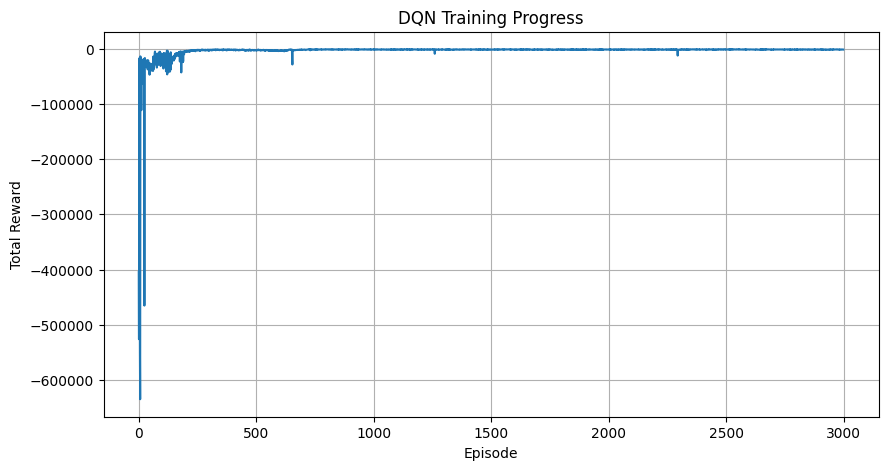

In [17]:
# TRAINING PERFORMANCE

plt.figure(figsize=(10,5))

plt.plot(reward_history)

plt.xlabel("Episode")
plt.ylabel("Total Reward")

plt.title("DQN Training Progress")

plt.grid()

plt.show()

In [18]:
# DQN-CONTROLLED SIMULATION

epsilon = 0.0

m_dot = 0.50
T_hot_in = 80.0

# Logging
T_log = []
m_log = []
dP_log = []
Tin_log = []
time_log = []

In [19]:
# CLOSED-LOOP CONTROL TEST

for step in range(200):

    # Disturbance
    if step > 100:
        T_hot_in = 70.0

    # Current state
    T_out = hx_model(
        m_dot,
        T_hot_in
    )

    dP = pressure_drop(
        m_dot
    )

    state = get_state(
        T_out,
        m_dot,
        T_hot_in
    )

    # Neural network chooses action
    state_tensor = torch.FloatTensor(
        state
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        q_values = model(state_tensor)

    action_index = torch.argmax(
        q_values
    ).item()

    action = actions[action_index]

    # Apply action
    m_dot = m_dot + action

    m_dot = np.clip(
        m_dot,
        0.05,
        1.0
    )

    # Logging
    T_log.append(T_out)
    m_log.append(m_dot)
    dP_log.append(dP)
    Tin_log.append(T_hot_in)
    time_log.append(step)

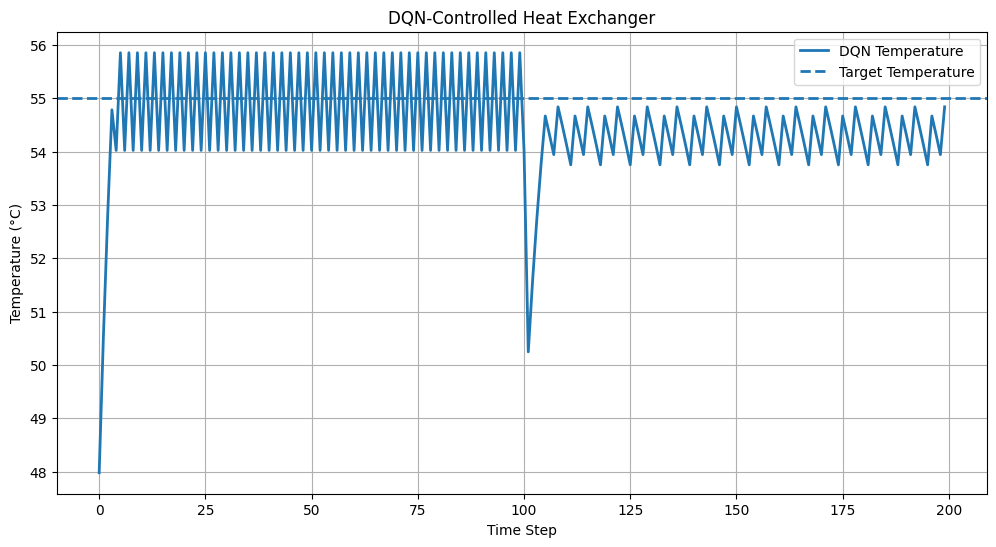

In [20]:
# TEMPERATURE RESPONSE

plt.figure(figsize=(12,6))

plt.plot(
    time_log,
    T_log,
    linewidth=2,
    label="DQN Temperature"
)

plt.axhline(
    T_target,
    linestyle='--',
    linewidth=2,
    label="Target Temperature"
)

plt.xlabel("Time Step")
plt.ylabel("Temperature (°C)")

plt.title("DQN-Controlled Heat Exchanger")

plt.legend()

plt.grid()

plt.show()


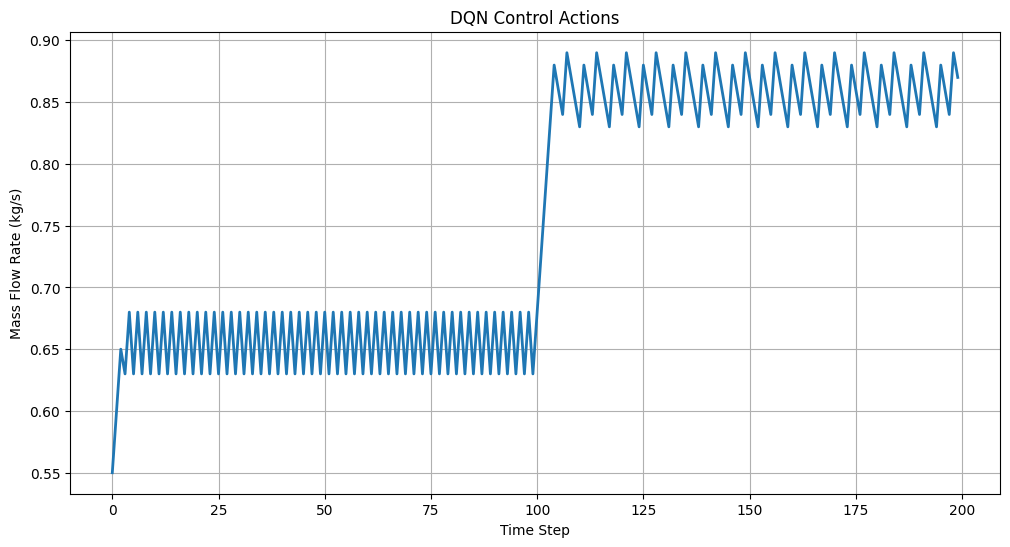

In [21]:
# CONTROL ACTIONS

plt.figure(figsize=(12,6))

plt.plot(
    time_log,
    m_log,
    linewidth=2
)

plt.xlabel("Time Step")
plt.ylabel("Mass Flow Rate (kg/s)")

plt.title("DQN Control Actions")

plt.grid()

plt.show()


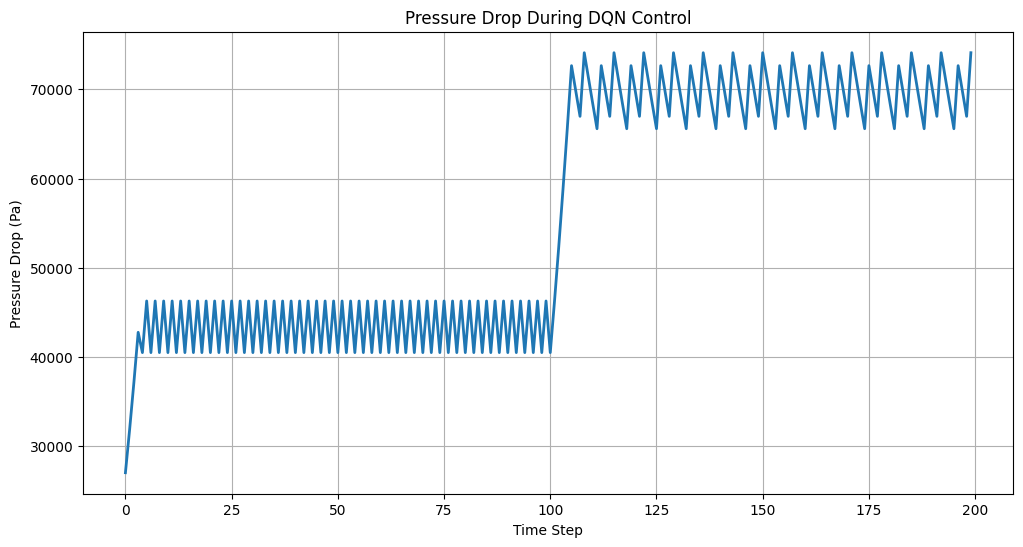

In [22]:
# PRESSURE DROP

plt.figure(figsize=(12,6))

plt.plot(
    time_log,
    dP_log,
    linewidth=2
)

plt.xlabel("Time Step")
plt.ylabel("Pressure Drop (Pa)")

plt.title("Pressure Drop During DQN Control")

plt.grid()

plt.show()

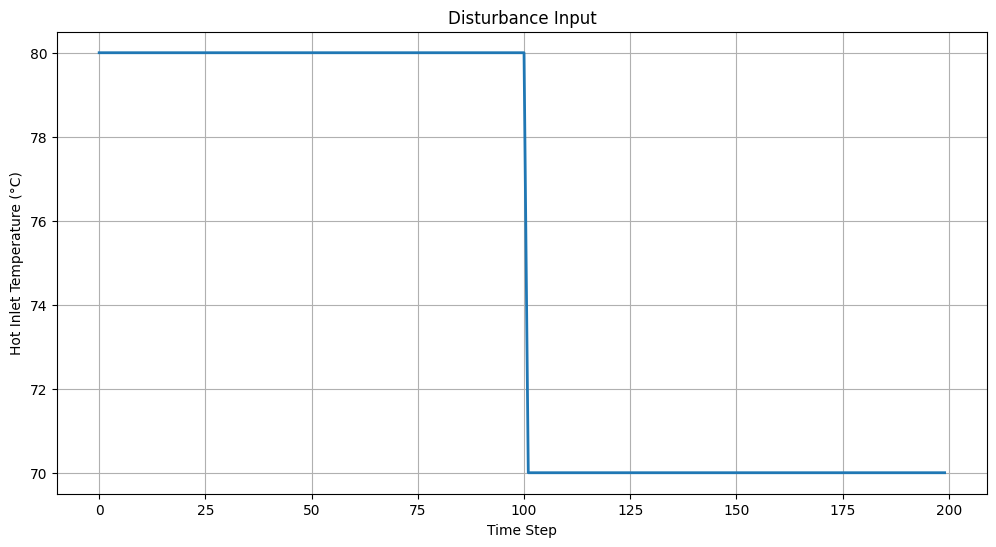

In [23]:
# DISTURBANCE PROFILE

plt.figure(figsize=(12,6))

plt.plot(
    time_log,
    Tin_log,
    linewidth=2
)

plt.xlabel("Time Step")
plt.ylabel("Hot Inlet Temperature (°C)")

plt.title("Disturbance Input")

plt.grid()

plt.show()

In [24]:
#saving a model
torch.save(model.state_dict(), 'model.pth')


In [30]:
#Adding various performances metrice
#IAE, ITAE, Transitinal Time,Steady-State Error
IAE = np.mean(np.abs(np.array(T_log) - T_target))
ITAE = np.max(np.abs(np.array(T_log) - T_target))
Transitinal_Time = np.argmax(np.abs(np.array(T_log) - T_target))

In [29]:
print(IAE)
print(ITAE)
print(Transitinal_Time)


0.898838147955685
7.020253415293595
0
